In [ ]:
from google.colab import files
uploaded = files.upload()

Saving messy_ecommerce_orders_8700_rows.csv to messy_ecommerce_orders_8700_rows.csv


In [ ]:
import os
print(os.listdir())

['.config', 'cleaned_data.csv', 'scaler.pkl', 'model.pkl', 'feature_columns.pkl', 'messy_ecommerce_orders_8700_rows.csv', 'feature_engineered_data.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("messy_ecommerce_orders_8700_rows.csv")
print(df.shape)
df.head()

(9187, 27)


,order_id,customer_id,customer_name,email,age,city,signup_date,loyalty_tier,product_id,product_name,...,quantity,unit_price,discount_pct,shipping_cost,order_status,return_flag,review_score,coupon_code,customer_note,reported_order_total
0,ORD-0004583,CUST-00307,Ahmed Qureshi,ahmed.qureshi3652@outlook.com,32.0,rawalpindi,11-13-2025,Gold,PROD-0004,Smart Watch,...,1,74.15,0.0,1.14,Cancelled,FALSE,3.0,FLASH20,customer asked for refund,75.29
1,ORD-0005967,CUST-01182,John Smith,john.smith8340@hotmail.com,125.0,sukkur,2025-10-17,Bronze,PROD-0010,Storage Box,...,1,36.85,0.0,6.65,Returned,Y,2.0,welcome10,great experience,43.5
2,ORD-0001183,CUST-00274,Mariam Lee,mariam.lee4558@hotmail.com,46.0,HYD,10-Aug-2024,NaN,PROD-0021,Feeding Bottle,...,3,59.61,5.0,0.56,NaN,NaN,3.0,NaN,no issue,170.45
3,ORD-0004686,CUST-02047,Ahmed Lee,ahmed.lee5586@gmail.com,44.0,MUX,16-Apr-2021,bronze,PROD-0009,LED Lamp,...,1,23.17,15.0,10.5,Returned,yes,NaN,NaN,wrong size sent,30.19
4,ORD-0005655,CUST-01084,Sara Shaikh,sara.shaikh9280@example.con,30.0,MEL,11-Nov-2021,Gold,PROD-0008,Vacuum Cleaner,...,3,33.26,10.0,7.31,Pending,NaN,NaN,NaN,package lost by courier,97.11


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(9187, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9187 entries, 0 to 9186
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              9187 non-null   object 
 1   customer_id           9122 non-null   object 
 2   customer_name         9089 non-null   object 
 3   email                 8799 non-null   object 
 4   age                   8795 non-null   float64
 5   city                  9089 non-null   object 
 6   signup_date           9089 non-null   object 
 7   loyalty_tier          6660 non-null   object 
 8   product_id            9125 non-null   object 
 9   product_name          9085 non-null   object 
 10  category              9085 non-null   object 
 11  brand                 8464 non-null   object 
 12  supplier_country      9085 non-null   object 
 13  order_date            9143 non-null   object 
 14  delivery_date         8092 non-null   object 
 15  sales_chan

In [ ]:
# Remove duplicates

In [ ]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows before: 467
Shape after removing duplicates: (8720, 27)


In [ ]:
print("Duplicate order IDs:", df['order_id'].duplicated().sum())
df = df.drop_duplicates(subset='order_id')
print("Shape after removing duplicate order IDs:", df.shape)

Duplicate order IDs: 220
Shape after removing duplicate order IDs: (8500, 27)


In [ ]:
#clean all text column
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
df[['category','payment_method','city']].head()

,category,payment_method,city
0,Electronics,cash on delivery,rawalpindi
1,home,CC,sukkur
2,Baby,PayPal,HYD
3,HOME,cash on delivery,MUX
4,Home,Debit Card,MEL


In [ ]:
print(df['return_flag'].value_counts(dropna=False))

return_flag
no       2523
n        1127
0        1106
yes       876
nan       813
false     810
y         475
true      397
1         373
Name: count, dtype: int64


In [ ]:
# standardize targer
mapping = {
    'yes': 1,
    'y': 1,
    'true': 1,
    '1': 1,

    'no': 0,
    'n': 0,
    'false': 0,
    '0': 0
}

df['return_flag'] = df['return_flag'].map(mapping)

In [ ]:
df = df.dropna(subset=['return_flag'])

In [ ]:
print(df['return_flag'].value_counts())

return_flag
0.0    1142
1.0     712
Name: count, dtype: int64


In [ ]:
# fix date column
date_cols = ['signup_date', 'order_date', 'delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

/tmp/ipykernel_2291/709223605.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [ ]:
df[date_cols].isnull().sum()

,0
signup_date,5808
order_date,5908
delivery_date,4462


In [ ]:
# convert numeric column
num_cols = [
    'quantity',
    'unit_price',
    'discount_pct',
    'shipping_cost',
    'review_score',
    'reported_order_total'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df[num_cols].dtypes

,0
quantity,float64
unit_price,float64
discount_pct,float64
shipping_cost,float64
review_score,float64
reported_order_total,float64


In [ ]:
# handlle missing value
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# handle missing categorical value
cat_cols = [
    'loyalty_tier',
    'sales_channel',
    'payment_method',
    'order_status',
    'coupon_code'
]

for col in cat_cols:
       df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
date_cols = ['signup_date', 'order_date', 'delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce',
        infer_datetime_format=True
    )

/tmp/ipykernel_2291/1788612110.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col] = pd.to_datetime(
/tmp/ipykernel_2291/1788612110.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col] = pd.to_datetime(
/tmp/ipykernel_2291/1788612110.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col] = pd.to_datetime(


In [ ]:
print(df[date_cols].isnull().sum())

signup_date      1435
order_date       1407
delivery_date    1094
dtype: int64


In [ ]:
df['signup_date'] = df['signup_date'].fillna(df['signup_date'].mode()[0])

In [ ]:
df['order_date'] = df['order_date'].fillna(df['order_date'].mode()[0])

In [ ]:
median_gap = 5

df['delivery_date'] = df['delivery_date'].fillna(
    df['order_date'] + pd.Timedelta(days=median_gap)
)

In [ ]:
df['delivery_time_days'] = (
    df['delivery_date'] - df['order_date']
).dt.days

df['delivery_time_days'] = df['delivery_time_days'].clip(lower=0)

In [ ]:
print("Total Missing:", df.isnull().sum().sum())
print(df.shape)

Total Missing: 595
(1854, 28)


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
customer_id,10
customer_name,16
email,77
age,63
city,16
product_id,15
product_name,22
category,22
brand,146
supplier_country,22


In [ ]:
# fill remaining missing values
for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    elif df[col].dtype == 'datetime64[ns]':
        df[col] = df[col].fillna(df[col].mode()[0])

    else:
        df[col] = df[col].fillna("unknown")

In [ ]:
print("Total Missing:", df.isnull().sum().sum())
print("Final Shape:", df.shape)

Total Missing: 0
Final Shape: (1854, 28)


In [ ]:
# save final cleaned data
df.to_csv("cleaned_data.csv", index=False)
print("Final cleaned dataset saved")

Final cleaned dataset saved


In [ ]:
# EDA

In [ ]:
# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

<Figure size 1200x600 with 0 Axes>

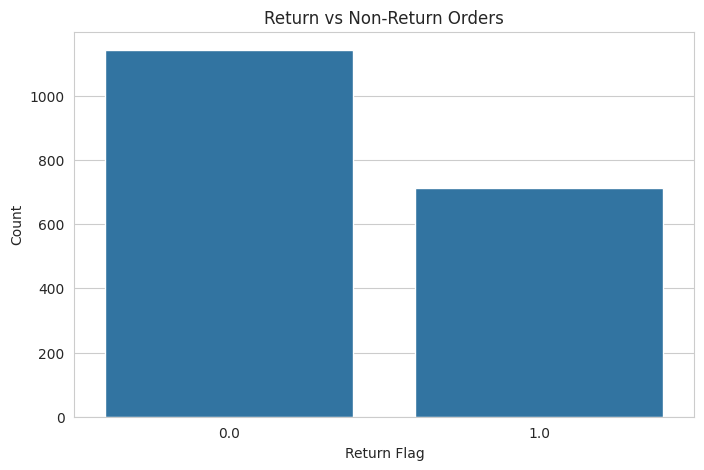

In [ ]:
# target variables analysis
plt.figure(figsize=(8,5))
sns.countplot(x='return_flag', data=df)

plt.title("Return vs Non-Return Orders")
plt.xlabel("Return Flag")
plt.ylabel("Count")
plt.show()

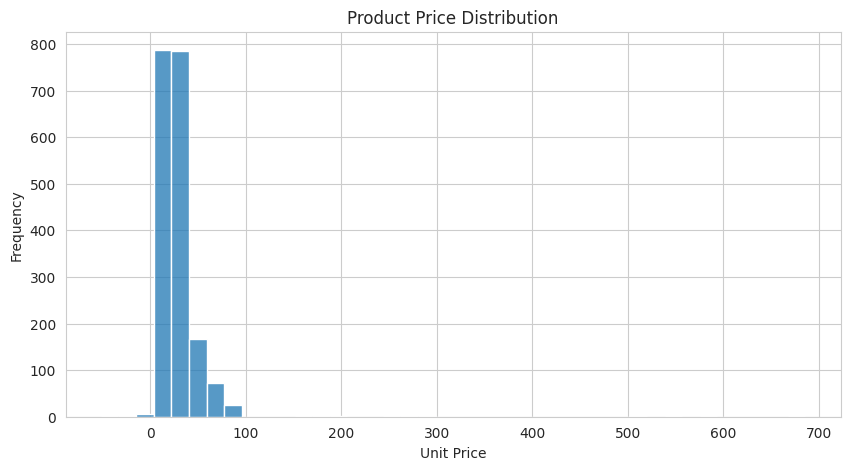

In [ ]:
# unit price distribution
plt.figure(figsize=(10,5))
sns.histplot(df['unit_price'], bins=40)

plt.title("Product Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

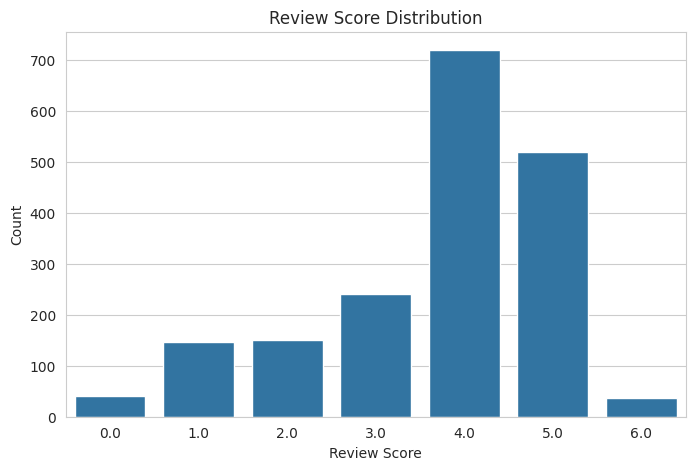

In [ ]:
# review score analysis
plt.figure(figsize=(8,5))
sns.countplot(x='review_score', data=df)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

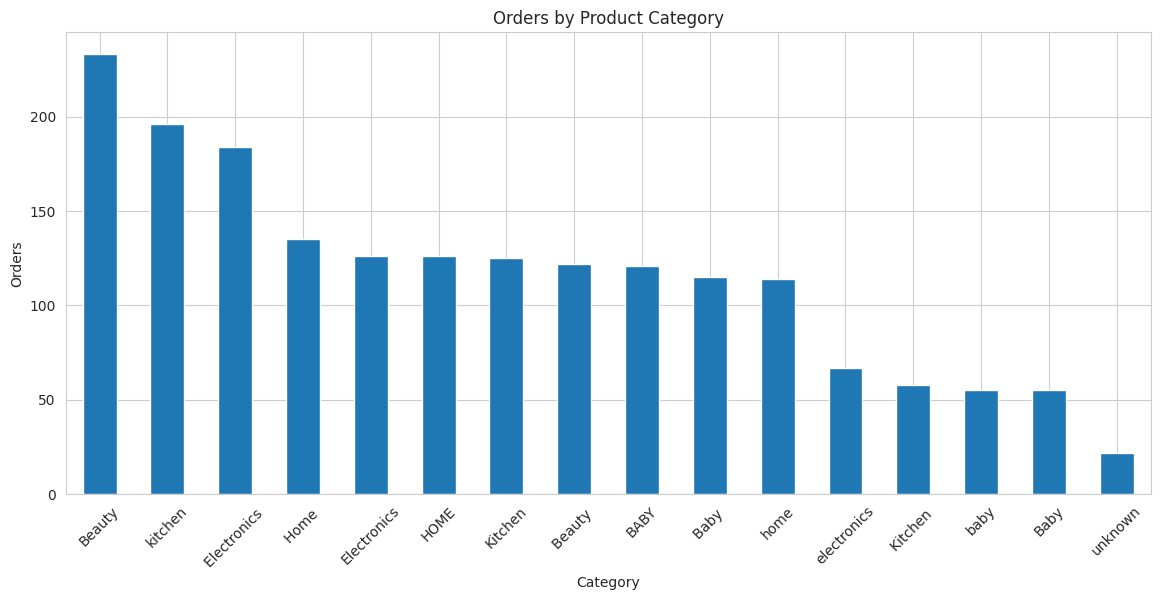

In [ ]:
# category performance
plt.figure(figsize=(14,6))
df['category'].value_counts().plot(kind='bar')

plt.title("Orders by Product Category")
plt.xlabel("Category")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

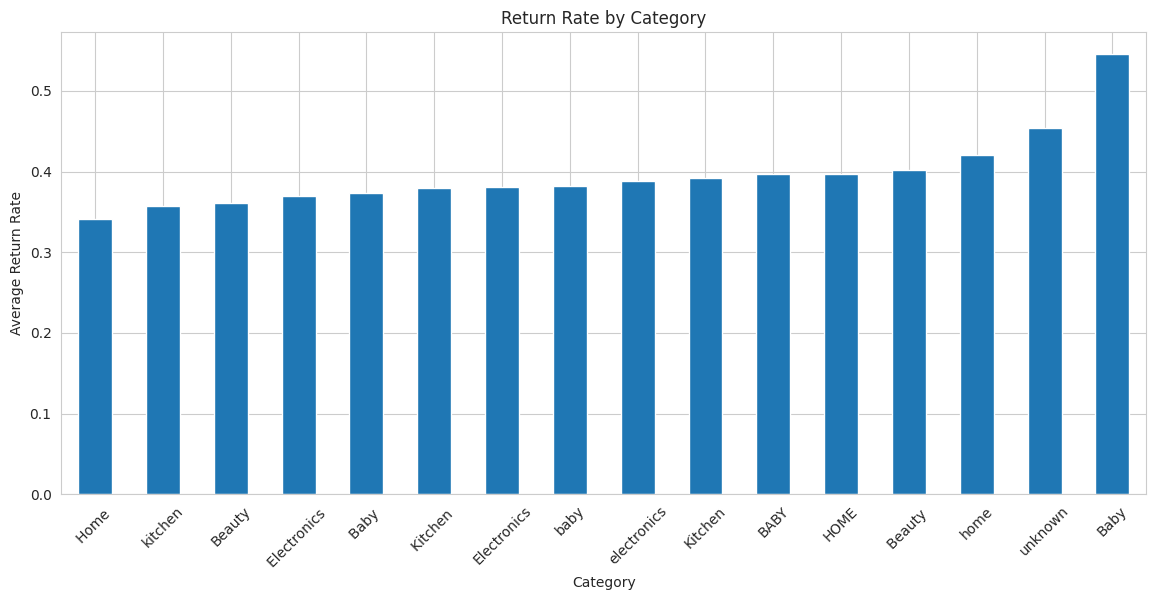

In [ ]:
# return rate by category
category_returns = df.groupby('category')['return_flag'].mean().sort_values()

plt.figure(figsize=(14,6))
category_returns.plot(kind='bar')

plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Average Return Rate")
plt.xticks(rotation=45)
plt.show()

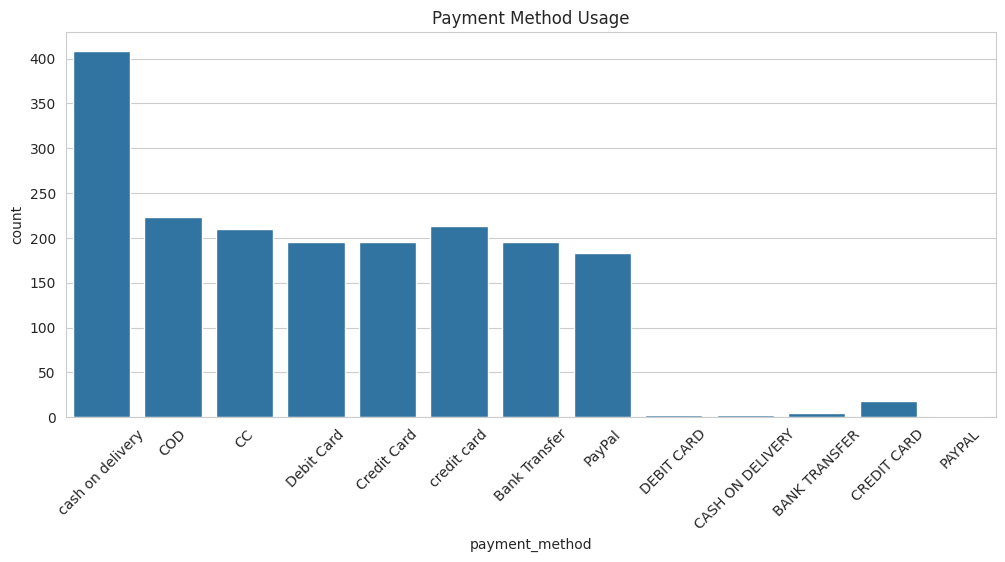

In [ ]:
# payment method analysis
plt.figure(figsize=(12,5))
sns.countplot(x='payment_method', data=df)

plt.title("Payment Method Usage")
plt.xticks(rotation=45)
plt.show()

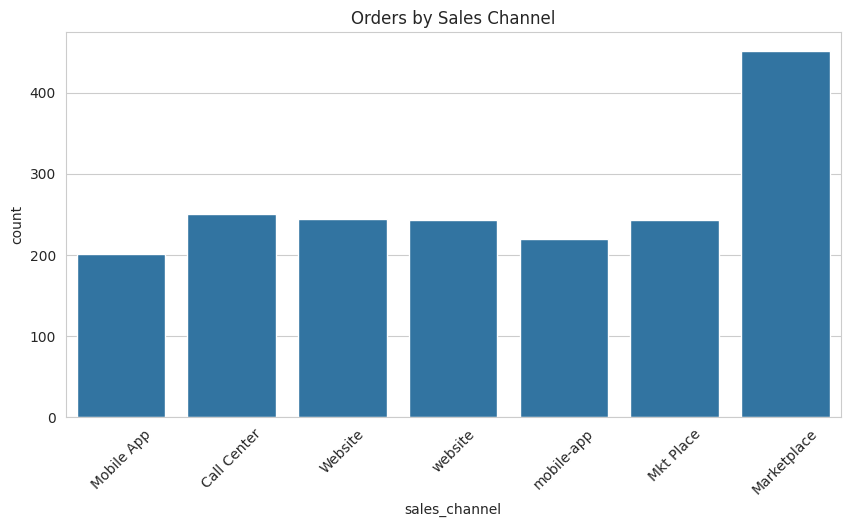

In [ ]:
# sales chalenge analysis
plt.figure(figsize=(10,5))
sns.countplot(x='sales_channel', data=df)

plt.title("Orders by Sales Channel")
plt.xticks(rotation=45)
plt.show()

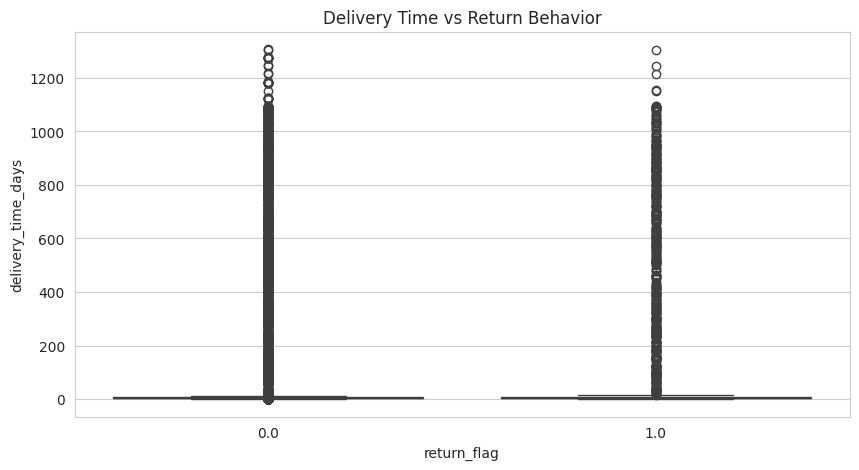

In [ ]:
# delivery time vs return
plt.figure(figsize=(10,5))
sns.boxplot(x='return_flag', y='delivery_time_days', data=df)

plt.title("Delivery Time vs Return Behavior")
plt.show()

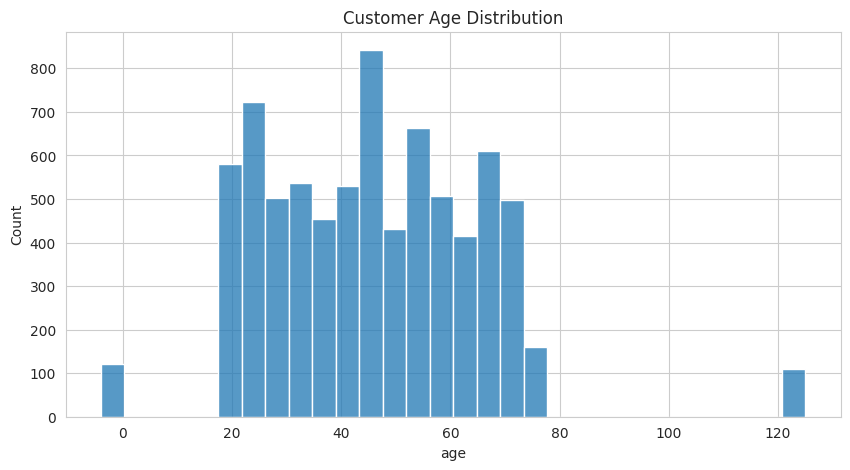

In [ ]:
# customer age distribution
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30)

plt.title("Customer Age Distribution")
plt.show()

In [ ]:
# monthly sales trends
df['order_month'] = df['order_date'].dt.month

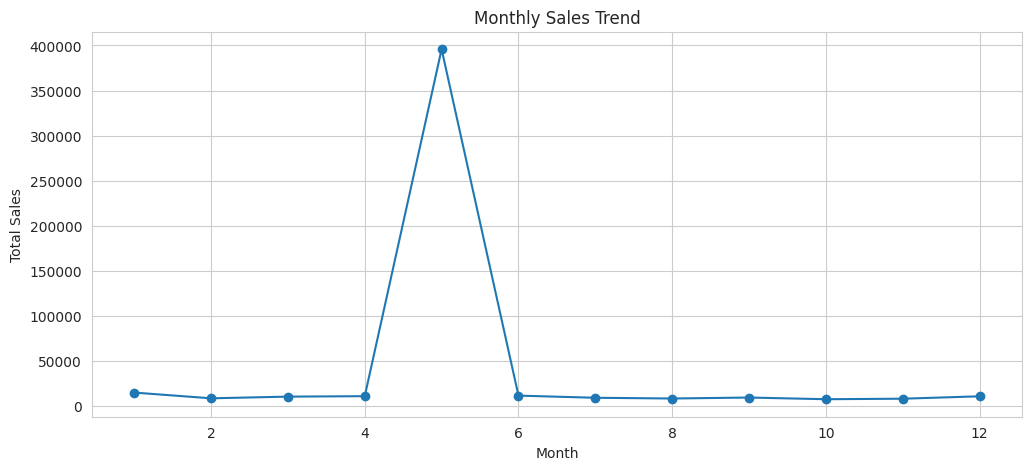

In [ ]:
monthly_sales = df.groupby('order_month')['reported_order_total'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

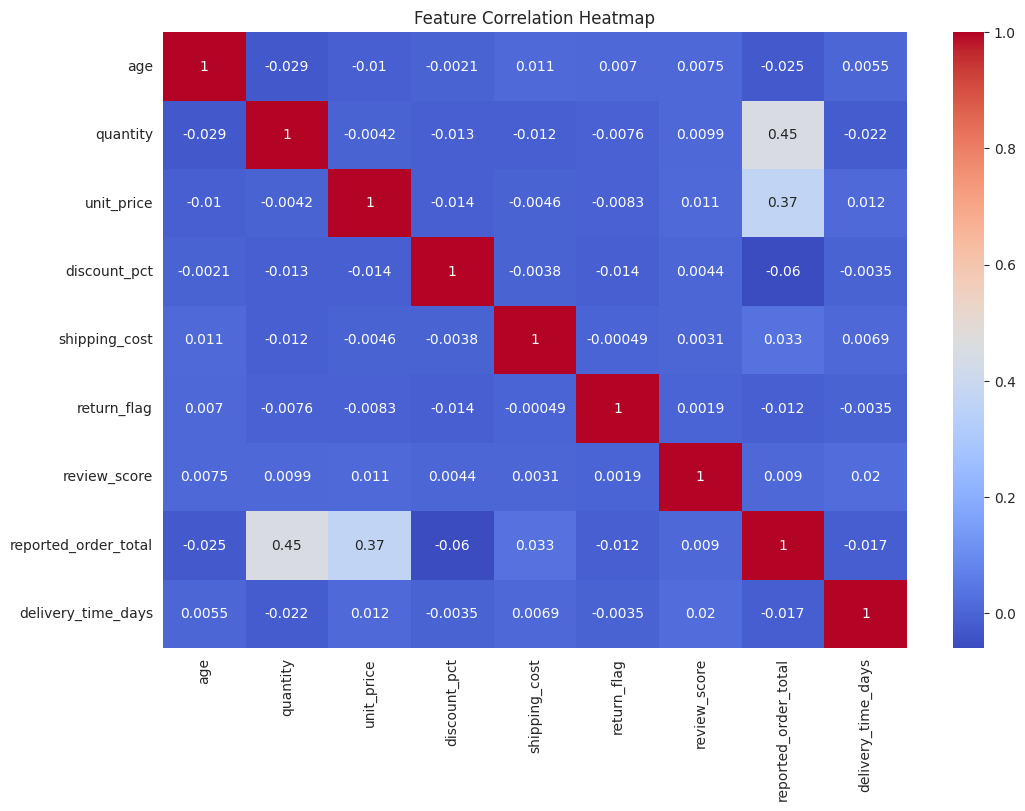

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

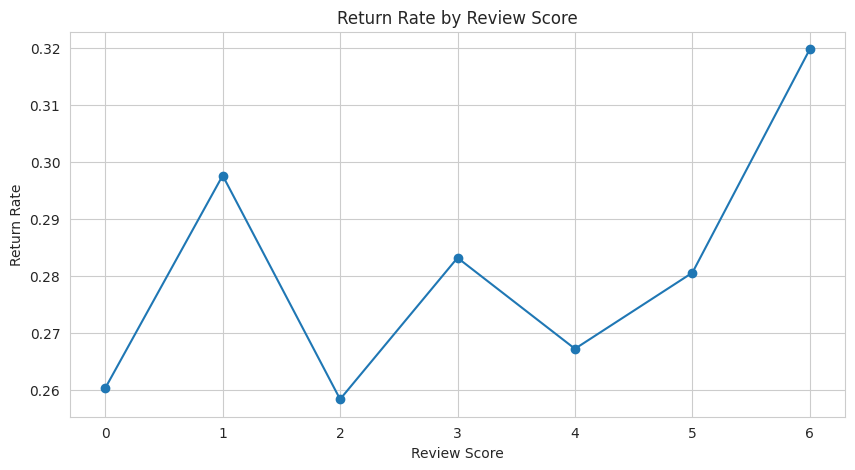

In [ ]:
# return rate by review score
review_returns = df.groupby('review_score')['return_flag'].mean()

plt.figure(figsize=(10,5))
review_returns.plot(marker='o')

plt.title("Return Rate by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Return Rate")
plt.show()

<Axes: xlabel='return_flag', ylabel='count'>

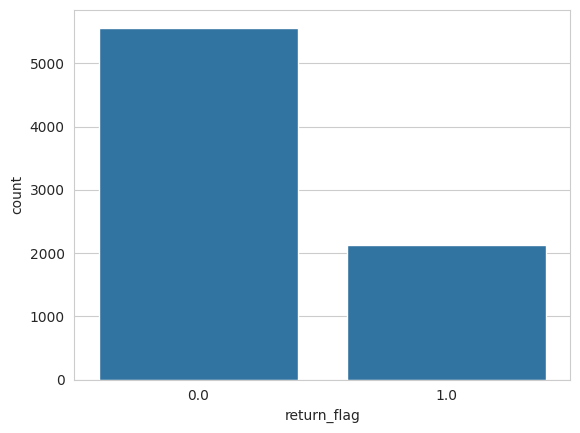

In [ ]:
sns.countplot(x='return_flag', data=df)

<Axes: xlabel='unit_price', ylabel='Count'>

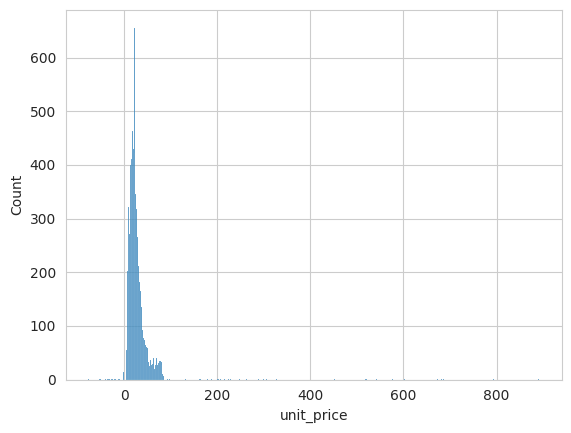

In [ ]:
sns.histplot(df['unit_price'])

In [ ]:
numeric_df.corr()

,age,quantity,unit_price,discount_pct,shipping_cost,return_flag,review_score,reported_order_total,delivery_time_days
age,1.000000,0.011958,-0.028766,-0.003894,0.022255,-0.019739,-0.004017,-0.017338,-0.044556
quantity,0.011958,1.000000,-0.012204,0.001006,-0.012873,-0.007766,0.023059,0.553156,-0.033929
unit_price,-0.028766,-0.012204,1.000000,-0.005224,-0.000043,-0.005660,0.009597,0.625111,0.021625
discount_pct,-0.003894,0.001006,-0.005224,1.000000,-0.013433,-0.009592,0.029376,-0.074901,0.022477
shipping_cost,0.022255,-0.012873,-0.000043,-0.013433,1.000000,0.002623,0.044324,0.038359,0.035939
return_flag,-0.019739,-0.007766,-0.005660,-0.009592,0.002623,1.000000,-0.016457,0.002466,-0.010482
review_score,-0.004017,0.023059,0.009597,0.029376,0.044324,-0.016457,1.000000,0.032232,-0.000280
reported_order_total,-0.017338,0.553156,0.625111,-0.074901,0.038359,0.002466,0.032232,1.000000,-0.021230
delivery_time_days,-0.044556,-0.033929,0.021625,0.022477,0.035939,-0.010482,-0.000280,-0.021230,1.000000


In [ ]:
df.to_csv("cleaned_data.csv", index=False)
print("File saved successfully")

File saved successfully


In [ ]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# load clean dataset
import pandas as pd

df = pd.read_csv("cleaned_data.csv")
print(df.shape)
df.head()

(7687, 29)


,order_id,customer_id,customer_name,email,age,city,signup_date,loyalty_tier,product_id,product_name,...,discount_pct,shipping_cost,order_status,return_flag,review_score,coupon_code,customer_note,reported_order_total,delivery_time_days,order_month
0,ord-0004583,cust-00307,ahmed qureshi,ahmed.qureshi3652@outlook.com,32.0,rawalpindi,2025-11-13,gold,prod-0004,smart watch,...,0.0,1.14,cancelled,0.0,3.0,flash20,customer asked for refund,75.29,0,12
1,ord-0005967,cust-01182,john smith,john.smith8340@hotmail.com,125.0,sukkur,2024-06-27,bronze,prod-0010,storage box,...,0.0,6.65,returned,1.0,2.0,welcome10,great experience,43.50,179,2
2,ord-0004686,cust-02047,ahmed lee,ahmed.lee5586@gmail.com,44.0,mux,2024-06-27,bronze,prod-0009,led lamp,...,15.0,10.50,returned,1.0,4.0,NaN,wrong size sent,30.19,606,5
3,ord-0002907,cust-00522,john smith,john.smith4636@gamil.com,72.0,karachi,2024-06-27,NaN,prod-0006,laptop stand,...,10.0,0.00,NaN,0.0,6.0,welcome10,customer asked for refund,42.16,5,5
4,ord-0006653,cust-01591,sara ahmed,sara.ahmed8895@outlook.com,52.0,fsd,2024-06-27,platinum,prod-0011,bedsheet set,...,20.0,4.52,pending,0.0,4.0,flash20,customer asked for refund,42.39,5,5


In [ ]:
# convert data columns
date_cols = ['signup_date', 'order_date', 'delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [ ]:
# convert order month feature
df['order_month'] = df['order_date'].dt.month

In [ ]:
# convert order weekday feature
df['order_weekday'] = df['order_date'].dt.dayofweek

In [ ]:
df['customer_tenure_days'] = (
    df['order_date'] - df['signup_date']
).dt.days

In [ ]:
df['customer_tenure_days'] = df['customer_tenure_days'].clip(lower=0)

In [ ]:
# create delivery delay flag
df['delayed_delivery_flag'] = (
    df['delivery_time_days'] > 7
).astype(int)

In [ ]:
#create total discount value
df['discount_value'] = (
    df['unit_price'] * df['quantity'] * df['discount_pct'] / 100
)

In [ ]:
# create final order value
df['final_order_value'] = (
    df['unit_price'] * df['quantity']
) - df['discount_value']

In [ ]:
# create avg item cost
df['avg_item_cost'] = (
    df['final_order_value'] / df['quantity']
)

In [ ]:
# high value order flag
threshold = df['final_order_value'].median()

df['high_value_order'] = (
    df['final_order_value'] > threshold
).astype(int)

In [ ]:
# review satisfaction flag
df['low_review_flag'] = (
    df['review_score'] <= 2
).astype(int)

In [ ]:
# shipping cost ratio
df['shipping_ratio'] = (
    df['shipping_cost'] / df['final_order_value']
)

In [ ]:
# check new feature
new_features = [
    'order_month',
    'order_weekday',
    'customer_tenure_days',
    'delayed_delivery_flag',
    'discount_value',
    'final_order_value',
    'avg_item_cost',
    'high_value_order',
    'low_review_flag',
    'shipping_ratio'
]

df[new_features].head()

,order_month,order_weekday,customer_tenure_days,delayed_delivery_flag,discount_value,final_order_value,avg_item_cost,high_value_order,low_review_flag,shipping_ratio
0,12,6,0,0,0.0000,74.1500,74.1500,1,0,0.015374
1,2,4,0,1,0.0000,36.8500,36.8500,1,1,0.180461
2,5,6,0,1,3.4755,19.6945,19.6945,0,0,0.533144
3,5,6,0,0,4.6840,42.1560,21.0780,1,0,0.000000
4,5,6,0,0,8.9600,35.8400,17.9200,1,0,0.126116


In [ ]:
df.to_csv("feature_engineered_data.csv", index=False)

print("Feature engineered dataset saved")

Feature engineered dataset saved


In [ ]:
# Data Processing

In [ ]:
# load dataset
import pandas as pd
df = pd.read_csv("feature_engineered_data.csv")
print(df.shape)

(7687, 38)


In [ ]:
# drop unnecessary column
drop_cols = [
    'order_id',
    'customer_id',
    'customer_name',
    'email',
    'product_id',
    'product_name',
    'customer_note',
    'coupon_code',
    'city',
    'brand',
    'order_status'
]

In [ ]:
# define target variable
y = df['return_flag']
X = df.drop('return_flag', axis=1)

In [ ]:
# identify category column
categorical_cols = X.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['order_id', 'customer_id', 'customer_name', 'email', 'city',
       'signup_date', 'loyalty_tier', 'product_id', 'product_name', 'category',
       'brand', 'supplier_country', 'order_date', 'delivery_date',
       'sales_channel', 'payment_method', 'order_status', 'coupon_code',
       'customer_note'],
      dtype='object')


In [ ]:
# one hot encode category column
categorical_cols = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)

(7687, 15215)


In [ ]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [ ]:
print(X.isnull().sum().sum())

0


In [ ]:
X.shape

(7687, 15215)

In [ ]:
# check unique value per column
for col in categorical_cols:
    print(col, ":", X[col].nunique() if col in X.columns else df[col].nunique())

order_id : 7687
customer_id : 2115
customer_name : 264
email : 2048
city : 25
signup_date : 454
loyalty_tier : 4
product_id : 31
product_name : 30
category : 5
brand : 6
supplier_country : 4
order_date : 1031
delivery_date : 1482
sales_channel : 6
payment_method : 7
order_status : 5
coupon_code : 3
customer_note : 9


In [ ]:
cat_check = df.select_dtypes(include=['object']).nunique().sort_values(ascending=False)
print(cat_check)

order_id            7687
customer_id         2115
email               2048
delivery_date       1482
order_date          1031
signup_date          454
customer_name        264
product_id            31
product_name          30
city                  25
customer_note          9
payment_method         7
sales_channel          6
brand                  6
category               5
order_status           5
loyalty_tier           4
supplier_country       4
coupon_code            3
dtype: int64


In [ ]:
date_cols_to_drop = [
    'signup_date',
    'order_date',
    'delivery_date'
]

df = df.drop(columns=date_cols_to_drop, errors='ignore')

In [ ]:
y = df['return_flag']
X = df.drop('return_flag', axis=1)

In [ ]:
# encode again
categorical_cols = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)

(7687, 12251)


In [ ]:
import numpy as np

# replace infinity with missing
X = X.replace([np.inf, -np.inf], np.nan)

# fill remaining missing values
X = X.fillna(0)

# check again
print("Missing values:", X.isnull().sum().sum())
print("Infinity values:", np.isinf(X.select_dtypes(include=[np.number])).sum().sum())

Missing values: 0
Infinity values: 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train:", X_train_scaled.shape)
print("Scaled test:", X_test_scaled.shape)

Scaled train: (6149, 12251)
Scaled test: (1538, 12251)


In [ ]:
# Model training

In [ ]:
# import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
# train logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [ ]:
# logistic regression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Logistic Regression Results
Accuracy: 0.8582574772431729
Precision: 0.8843283582089553
Recall: 0.5589622641509434
F1 Score: 0.684971098265896


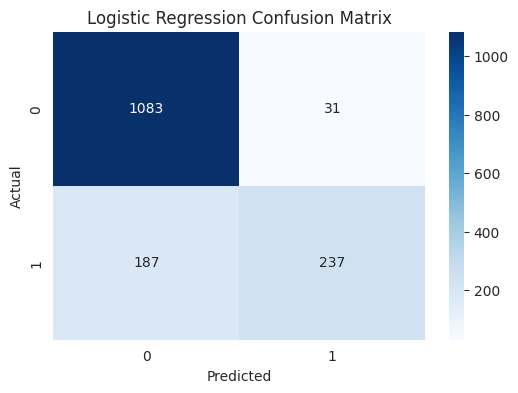

In [ ]:
# confusion matrics
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Decision Tree
# train decision tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

Decision Tree Results
Accuracy: 0.9577373211963589
Precision: 0.959079283887468
Recall: 0.8844339622641509
F1 Score: 0.9202453987730062


In [ ]:
# Random forest
# train random forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 0.9674902470741222
Precision: 1.0
Recall: 0.8820754716981132
F1: 0.9373433583959899


In [ ]:
print([col for col in X.columns if 'order_status' in col])

['order_status_delivered', 'order_status_pending', 'order_status_returned', 'order_status_shipped']


In [ ]:
# xboost
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

XGBoost Results
Accuracy: 0.9668400520156046
Precision: 0.9973333333333333
Recall: 0.8820754716981132
F1 Score: 0.9361702127659575


In [ ]:
# extract feature importance (show the top 15 most important features.)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
12239,order_status_returned,0.444827
12237,order_status_delivered,0.027652
12240,order_status_shipped,0.012534
12238,order_status_pending,0.012189
17,shipping_ratio,0.009920
14,avg_item_cost,0.009611
2,unit_price,0.009600
4,shipping_cost,0.008852
13,final_order_value,0.008664
6,reported_order_total,0.008352


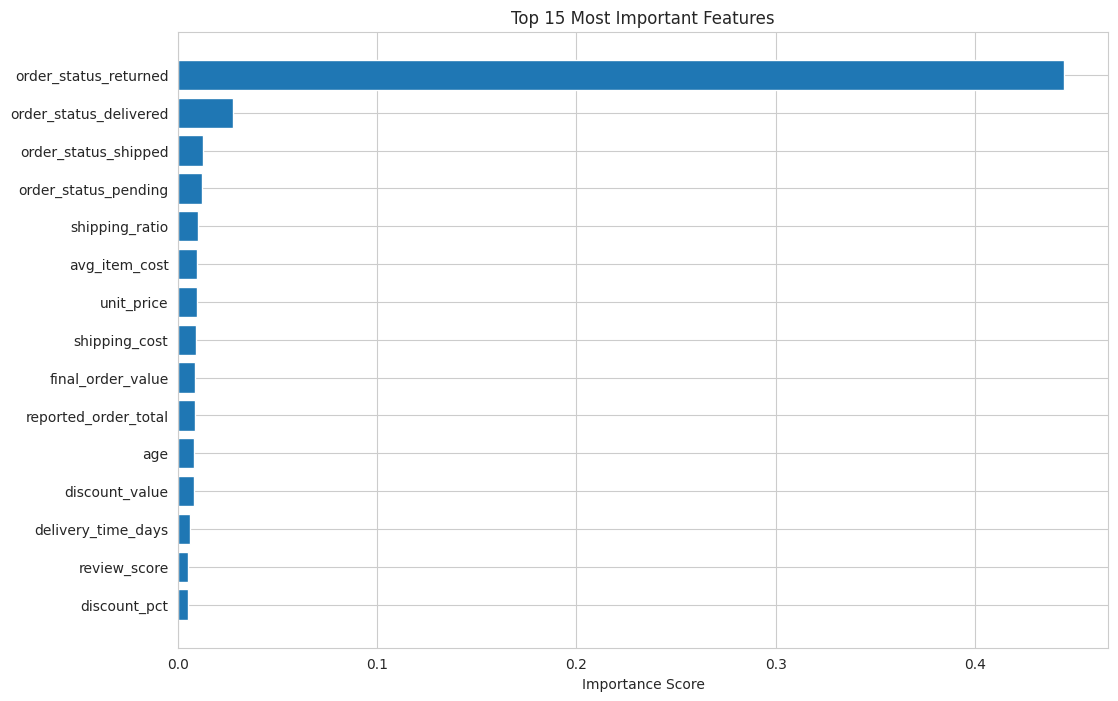

In [ ]:
# visualize feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance['Feature'][:15],
    feature_importance['Importance'][:15]
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print(feature_importance.head(5))

                      Feature  Importance
12239   order_status_returned    0.444827
12237  order_status_delivered    0.027652
12240    order_status_shipped    0.012534
12238    order_status_pending    0.012189
17             shipping_ratio    0.009920


In [ ]:
feature_importance.head(10)

,Feature,Importance
12239,order_status_returned,0.444827
12237,order_status_delivered,0.027652
12240,order_status_shipped,0.012534
12238,order_status_pending,0.012189
17,shipping_ratio,0.009920
14,avg_item_cost,0.009611
2,unit_price,0.009600
4,shipping_cost,0.008852
13,final_order_value,0.008664
6,reported_order_total,0.008352


In [ ]:
df = df.drop(columns=['order_status'], errors='ignore')

In [ ]:
print('order_status' in df.columns)

False


In [ ]:
y = df['return_flag']
X = df.drop('return_flag', axis=1)

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)

(7687, 12247)


In [ ]:
print([col for col in X.columns if 'order_status' in col])

[]


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 0.7230169050715215
Precision: 0.375
Recall: 0.007075471698113208
F1: 0.013888888888888888


In [ ]:
print([col for col in X.columns if 'order_status' in col])

[]


In [ ]:
# apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(8904, 12247)
return_flag
0.0    4452
1.0    4452
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 0.7230169050715215
Precision: 0.375
Recall: 0.007075471698113208
F1: 0.013888888888888888


In [ ]:
# save trained model
import joblib
joblib.dump(rf, "model.pkl")
print("Model saved successfully")

Model saved successfully


In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# reload final dataset
df = pd.read_csv("feature_engineered_data.csv")

# remove leakage + unnecessary columns
drop_cols = [
    'order_id',
    'customer_id',
    'customer_name',
    'email',
    'product_id',
    'product_name',
    'customer_note',
    'coupon_code',
    'city',
    'brand',
    'order_status',
    'signup_date',
    'order_date',
    'delivery_date'
]

df = df.drop(columns=drop_cols, errors='ignore')

# define target and features
y = df['return_flag']
X = df.drop('return_flag', axis=1)

# encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# clean infinity / missing
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train final model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

# save files
joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

df.to_csv("cleaned_data.csv", index=False)

print("\nAll files saved successfully")

Accuracy: 0.7204161248374512
Precision: 0.25
Recall: 0.007075471698113208
F1: 0.013761467889908258

All files saved successfully
